# Séries Temporais - Decomposição de Séries



---

## Introdução Teórica à Decomposição de Séries Temporais

Na análise de séries temporais, o objetivo fundamental é compreender a estrutura subjacente dos dados observados ao longo do tempo. Uma abordagem clássica e extremamente poderosa é a **Decomposição de Séries Temporais**, que assume que uma série temporal $X_t$ pode ser desmembrada em componentes estruturais ortogonais ou independentes:

1. **Tendência ($T_t$):** O movimento de longo prazo na média da série. Representa a direção geral para a qual os dados estão evoluindo (crescimento ou decrescimento).
2. **Sazonalidade ($S_t$):** Flutuações cíclicas que se repetem em intervalos regulares e previsíveis (por exemplo, mensal, trimestral ou semanal) devido a fatores sazonais (clima, feriados, calendários comerciais).
3. **Ruído ou Resíduo ($E_t$ ou $I_t$):** A componente aleatória, irregular ou estocástica. Representa choques de curto prazo não planejados e ruído de medição. Espera-se que idealmente comporte-se como um processo de ruído branco (média zero, variância constante e ausência de autocorrelação).

### Modelos de Formulação Clássica

* **Modelo Aditivo:** Utilizado quando a amplitude da variação sazonal permanece aproximadamente constante, independentemente do nível da tendência.
  $$X_t = T_t + S_t + E_t$$

* **Modelo Multiplicativo:** Utilizado quando a amplitude da variação sazonal é proporcional ao nível da tendência (ou seja, se a série cresce, as oscilações sazonais também aumentam de magnitude).
  $$X_t = T_t \times S_t \times E_t$$
  


## 1. Instalação e Importação de Bibliotecas

Utilizaremos o `statsmodels` (para modelagem estatística robusta), `pandas` (para manipulação de estruturas temporais) e `matplotlib`/`seaborn` (para visualização de dados).

In [2]:
# Caso não tenha as bibliotecas instaladas, execute a linha abaixo retirando o comentário:
# pip install pandas numpy statsmodels matplotlib seaborn openpyxl scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

## 2. Carregando a Base de Dados

Carregaremos o conjunto de dados `AirPassengers` a partir de uma planilha Excel (`AirPassengers.xlsx`).

No Python podemos trabalhar com o `DatetimeIndex` do `pandas`, definindo explicitamente a frequência temporal para que os algoritmos estatísticos operem corretamente.

In [3]:
df = sns.load_dataset("flights")
df.head
#Renomeando colunas para consistência, se necessário
df.columns = ['Year','Month', 'Passengers']

In [4]:
df

,Year,Month,Passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [5]:
data_string = df['Year'].astype(str) + '-' + df['Month'].astype(str)

df['Date'] = pd.to_datetime(data_string, format='%Y-%b')

# Configurando a nova coluna como o Índice da Série Temporal
df.set_index('Date', inplace=True)

# 4. Definindo a frequência como Início do Mês (Monthly Start)
df.index.freq = 'MS'

# 5. Criando a variável AP contendo apenas a Série Temporal
AP = df['Passengers']

print("\nSérie Temporal 'AP' configurada com sucesso!")
print("Estrutura do Índice Temporal ajustado:")
print(AP.head())


Série Temporal 'AP' configurada com sucesso!
Estrutura do Índice Temporal ajustado:
Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: Passengers, dtype: int64


## 3. Análise Descritiva



### Verificando a classe e o tipo dos dados

In [6]:
print("Classe do objeto no Python:", type(AP))
print("Tipo de dado dos elementos:", AP.dtype)
print("Estrutura do Índice Temporal:\n", AP.index)

Classe do objeto no Python: <class 'pandas.core.series.Series'>
Tipo de dado dos elementos: int64
Estrutura do Índice Temporal:
 DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Date', length=144, freq='MS')


### Valores Ausentes (Missing Values)


In [7]:
missing_values = AP.isna().sum()
print(f"Quantidade de valores ausentes na série: {missing_values}")

Quantidade de valores ausentes na série: 0


### Frequência da Série
Retorna o número de observações por unidade de tempo (12 para mensal).

In [8]:
print("Frequência inferida pelo pandas:", AP.index.inferred_freq)
print("Períodos por ciclo anual (Sazonalidade clássica): 12")

Frequência inferida pelo pandas: MS
Períodos por ciclo anual (Sazonalidade clássica): 12


### Ciclo da Série
Retorna a posição de cada observação no ciclo (ex: meses de 1 a 12).

In [9]:
# Mostrando a posição cíclica das primeiras 15 observações (Mês da observação)
print("Ciclo das observações (Mês correspondente):")
print(AP.index.month[:15].values)

Ciclo das observações (Mês correspondente):
[ 1  2  3  4  5  6  7  8  9 10 11 12  1  2  3]


### Sumário Estatístico

In [10]:
print(AP.describe())

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64


### Plotando o Gráfico da Série Temporal


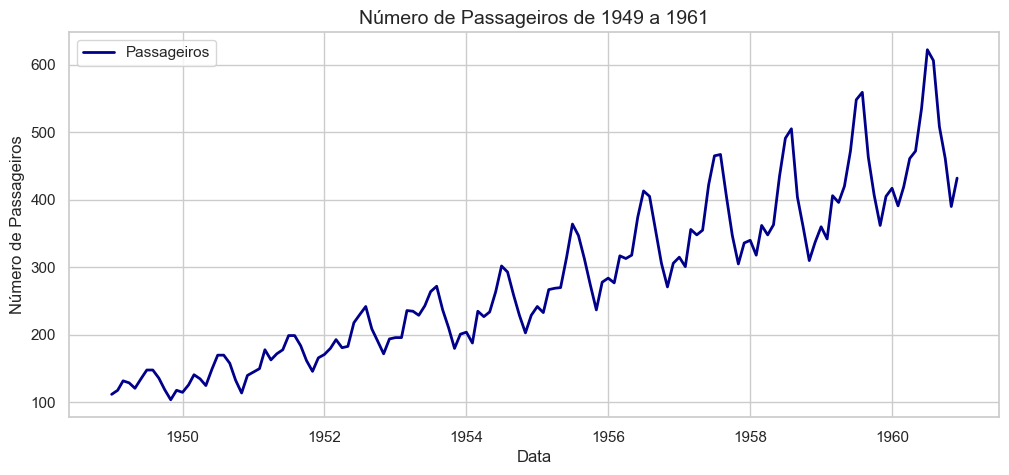

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(AP.index, AP.values, color='darkblue', linewidth=2, label='Passageiros')
plt.title('Número de Passageiros de 1949 a 1961', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Passageiros', fontsize=12)
plt.legend(loc='upper left')
plt.show()

## 4. Decomposição Clássica Automática

Utilizaremos a função `seasonal_decompose` do pacote `statsmodels.tsa.seasonal` para realizar as decomposições clássicas.

### 4.1 Decomposição Aditiva


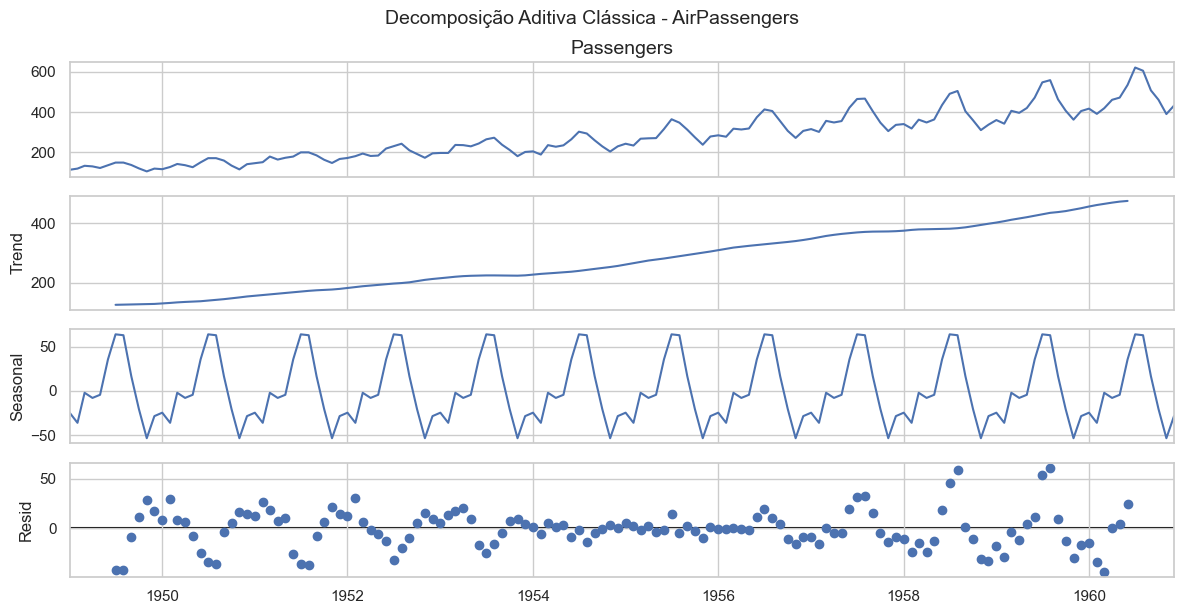

In [12]:
# Executando decomposição aditiva
decomposição_aditiva = seasonal_decompose(AP, model='additive', period=12)

# Plotando os componentes de forma elegante
fig = decomposição_aditiva.plot()
fig.suptitle('Decomposição Aditiva Clássica - AirPassengers', fontsize=14, y=1.02)
plt.show()

Para avaliar se uma decomposição foi adequada, devemos analisar rigorosamente a componente de **ruído (resíduo)**. O ruído deve idealmente se comportar como um processo puramente estocástico aleatório (Ruído Branco). 

No caso da decomposição aditiva aplicada aos dados da `AirPassengers`, observamos nitidamente que a variância do resíduo cresce no final da série, acompanhando o crescimento da tendência, e apresenta um padrão oscilatório remanescente. Isso indica que o modelo aditivo falhou em capturar a estrutura multiplicativa intrínseca dos dados (onde a variabilidade sazonal se expande proporcionalmente ao nível da série).

### 4.2 Decomposição Multiplicativa


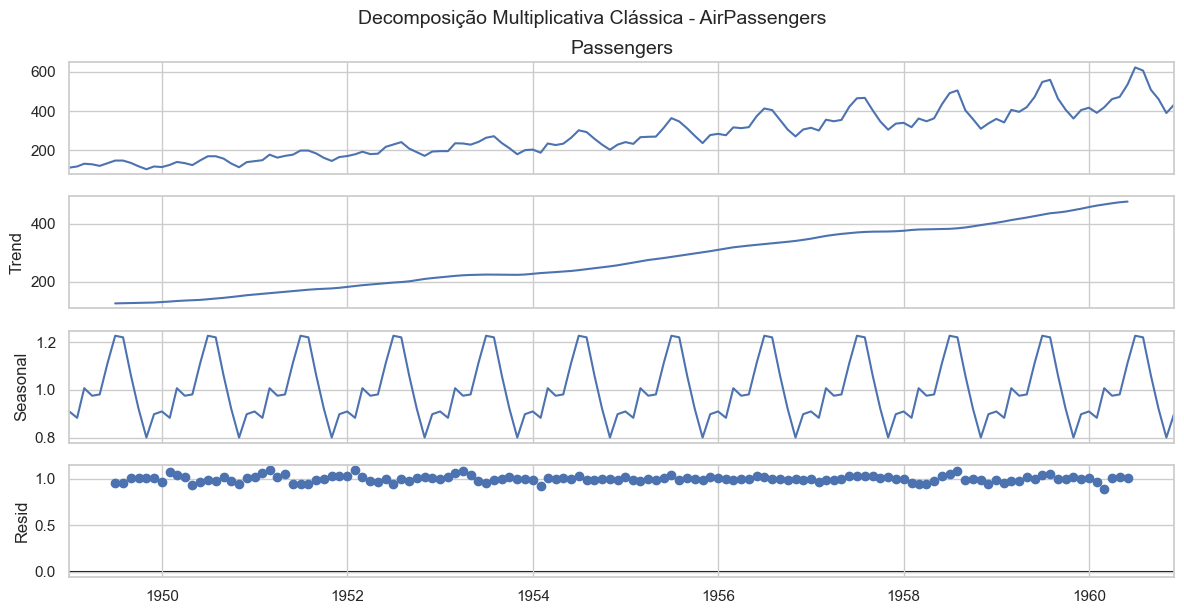

In [13]:
# Executando decomposição multiplicativa
decomposição_multiplicativa = seasonal_decompose(AP, model='multiplicative', period=12)

# Plotando os componentes
fig = decomposição_multiplicativa.plot()
fig.suptitle('Decomposição Multiplicativa Clássica - AirPassengers', fontsize=14, y=1.02)
plt.show()

Observe como no modelo multiplicativo a componente de resíduo estabiliza-se muito melhor ao redor do valor 1.0 (escala multiplicativa), sem apresentar a expansão de variância observada no modelo aditivo. Portanto, para a série `AirPassengers`, a formulação multiplicativa é estatisticamente muito mais adequada.

## 5. Passo a Passo Matemático da Decomposição (Implementação Manual)

Para solidificar os conceitos teóricos, vamos construir manualmente os métodos de estimação de tendência por regressão, filtros de médias móveis e extração de sazonalidade, espelhando perfeitamente a lógica executada no código R original.

### 5.1 Estimação de Tendência via Modelo Linear
Ajustamos um modelo de regressão linear simples onde a variável explicativa é o próprio vetor de tempo estruturado.

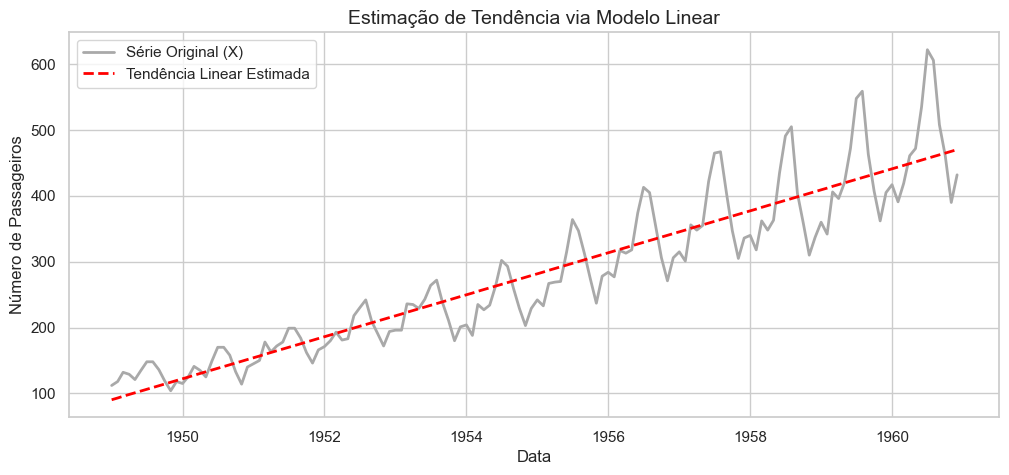

In [14]:
# Definindo a variável X e o vetor de tempo numérico
X = AP.values
tempo = np.arange(len(X)).reshape(-1, 1)

# Ajustando o modelo linear clássico (OLS)
X_com_constante = sm.add_constant(tempo)
modelo_linear = sm.OLS(X, X_com_constante).fit()
valores_ajustados_lin = modelo_linear.predict(X_com_constante)

# Visualização gráfica do ajuste da tendência
plt.figure(figsize=(12, 5))
plt.plot(AP.index, X, label='Série Original (X)', color='darkgrey', linewidth=2)
plt.plot(AP.index, valores_ajustados_lin, label='Tendência Linear Estimada', color='red', linestyle='--', linewidth=2)
plt.title('Estimação de Tendência via Modelo Linear', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### 5.2 Estimação de Tendência via Modelo Polinomial


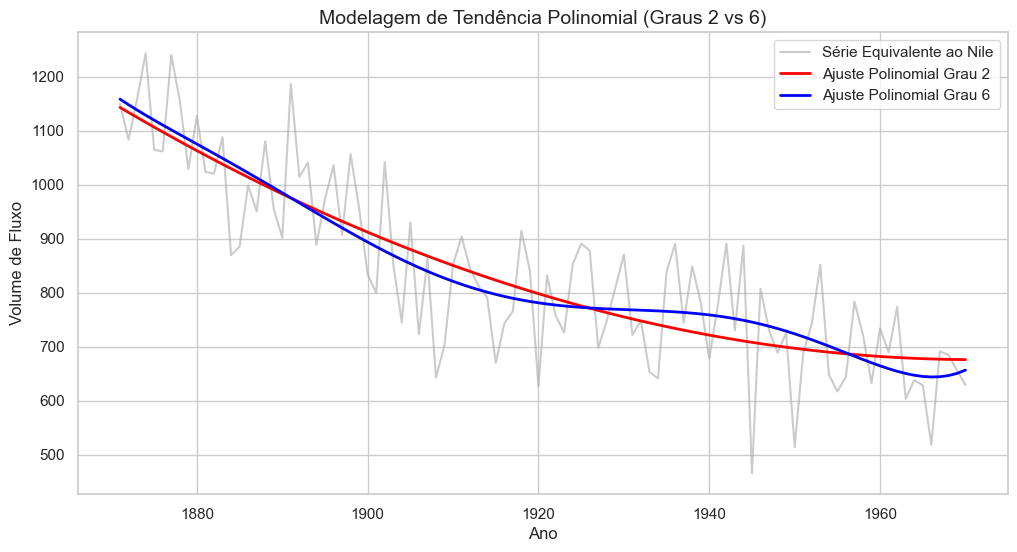

In [15]:
# Criando uma série sintética simulando a série 'Nile'
np.random.seed(42)
anos_nile = pd.date_range(start='1871-01-01', end='1970-12-01', freq='YS')
n = len(anos_nile)
# Gerando um comportamento de quebra de regime e decaimento não-linear semelhante ao Rio Nilo
valores_nile = 1100 - 3 * np.arange(n) - 150 * (np.arange(n) > 28) + np.random.normal(0, 100, n)
X_nile = pd.Series(valores_nile, index=anos_nile)

tempo_nile = np.arange(len(X_nile)).reshape(-1, 1)

# 1. Polinômio de Grau 2
poly2 = PolynomialFeatures(degree=2)
tempo_poly2 = poly2.fit_transform(tempo_nile)
model_p2 = sm.OLS(X_nile.values, tempo_poly2).fit()
fitted_p2 = model_p2.predict(tempo_poly2)

# 2. Polinômio de Grau 6
poly6 = PolynomialFeatures(degree=6)
tempo_poly6 = poly6.fit_transform(tempo_nile)
model_p6 = sm.OLS(X_nile.values, tempo_poly6).fit()
fitted_p6 = model_p6.predict(tempo_poly6)

# Plotagem comparativa
plt.figure(figsize=(12, 6))
plt.plot(X_nile.index, X_nile.values, color='darkgrey', alpha=0.6, label='Série Equivalente ao Nile')
plt.plot(X_nile.index, fitted_p2, color='red', linewidth=2, label='Ajuste Polinomial Grau 2')
plt.plot(X_nile.index, fitted_p6, color='blue', linewidth=2, label='Ajuste Polinomial Grau 6')
plt.title('Modelagem de Tendência Polinomial (Graus 2 vs 6)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Volume de Fluxo')
plt.legend()
plt.show()

### 5.3 Médias Móveis de Valores Passados (Causais)
Filtros causais olham puramente para trás no tempo. No Python, implementamos de maneira nativa e elegante com a função `.rolling()` do pandas.

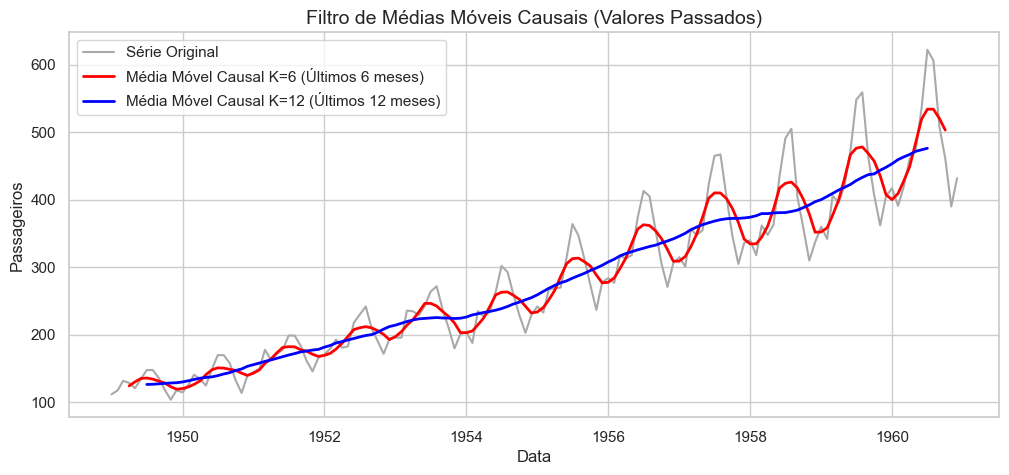

Nota de Aula: Quanto maior a ordem K da média móvel, maior é o nível de suavização da curva, porém maior é o atraso introduzido na série.


In [16]:
# Calculando médias móveis causais (alinhamento padrão à direita no pandas)
sma6 = AP.rolling(window=6, center=True).mean()
sma12 = AP.rolling(window=12, center=True).mean()

# Plotando os resultados
plt.figure(figsize=(12, 5))
plt.plot(AP.index, AP.values, color='darkgrey', label='Série Original')
plt.plot(AP.index, sma6, color='red', linewidth=2, label='Média Móvel Causal K=6 (Últimos 6 meses)')
plt.plot(AP.index, sma12, color='blue', linewidth=2, label='Média Móvel Causal K=12 (Últimos 12 meses)')
plt.title('Filtro de Médias Móveis Causais (Valores Passados)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.show()

print("Nota de Aula: Quanto maior a ordem K da média móvel, maior é o nível de suavização da curva, porém maior é o atraso introduzido na série.")

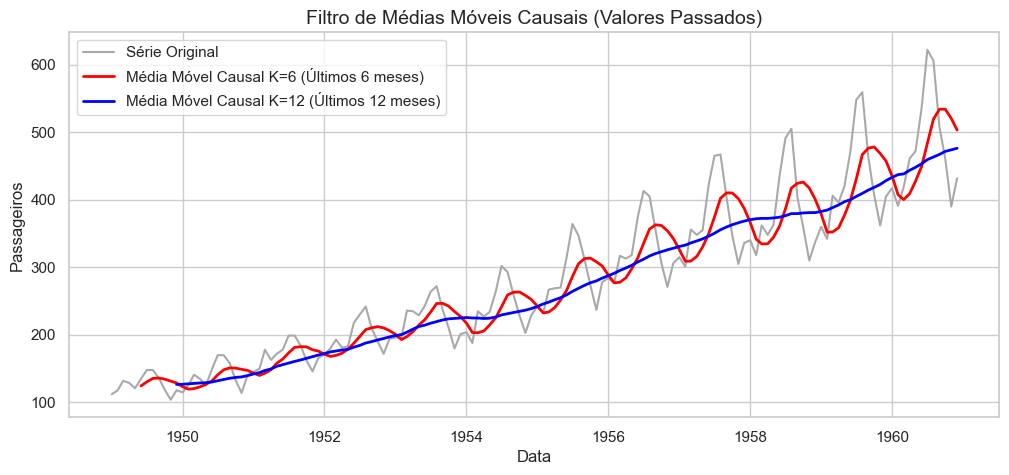

Nota de Aula: Quanto maior a ordem K da média móvel, maior é o nível de suavização da curva, porém maior é o atraso introduzido na série.


In [17]:
# Calculando médias móveis causais (alinhamento padrão à direita no pandas)
sma6 = AP.rolling(window=6).mean()
sma12 = AP.rolling(window=12).mean()

# Plotando os resultados
plt.figure(figsize=(12, 5))
plt.plot(AP.index, AP.values, color='darkgrey', label='Série Original')
plt.plot(AP.index, sma6, color='red', linewidth=2, label='Média Móvel Causal K=6 (Últimos 6 meses)')
plt.plot(AP.index, sma12, color='blue', linewidth=2, label='Média Móvel Causal K=12 (Últimos 12 meses)')
plt.title('Filtro de Médias Móveis Causais (Valores Passados)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.show()

print("Nota de Aula: Quanto maior a ordem K da média móvel, maior é o nível de suavização da curva, porém maior é o atraso introduzido na série.")

### 5.4 Médias Móveis Simétricas vs. Causais
As médias móveis simétricas distribuem os pesos igualmente ao redor da observação central $t$ (passado e futuro local). Em Python, aplicamos o parâmetro `center=True` dentro do método `.rolling()`, para informar que estamos utilizando o metodo simétrico

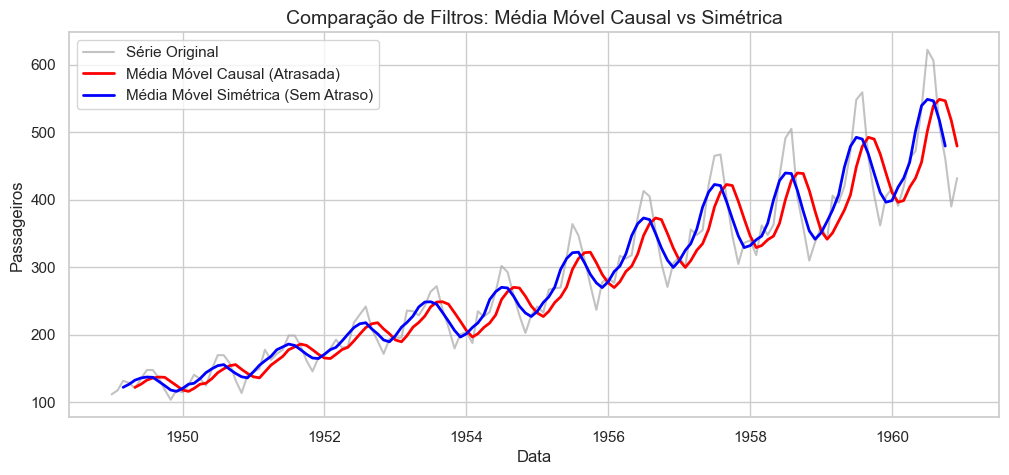

Conclusão Estatística: A média móvel baseada em valores passados (causal) apresenta um atraso sistemático em relação aos pontos de inflexão reais da série.
A média móvel simétrica corrige esse atraso, tornando-se o filtro padrão para decomposições clássicas offline, embora gere perdas de dados nas extremidades (NaNs).


In [18]:
# Ordem K = 5 para comparação justa
pass_ma = AP.rolling(window=5).mean()              # Passados 
sim_ma  = AP.rolling(window=5, center=True).mean() # Simétrica 

# Plotando e comparando o efeito de defasagem
plt.figure(figsize=(12, 5))
plt.plot(AP.index, AP.values, color='darkgrey', alpha=0.7, label='Série Original')
plt.plot(AP.index, pass_ma, color='red', linewidth=2, label='Média Móvel Causal (Atrasada)')
plt.plot(AP.index, sim_ma, color='blue', linewidth=2, label='Média Móvel Simétrica (Sem Atraso)')
plt.title('Comparação de Filtros: Média Móvel Causal vs Simétrica', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.show()

print("Conclusão Estatística: A média móvel baseada em valores passados (causal) apresenta um atraso sistemático em relação aos pontos de inflexão reais da série.")
print("A média móvel simétrica corrige esse atraso, tornando-se o filtro padrão para decomposições clássicas offline, embora gere perdas de dados nas extremidades (NaNs).")

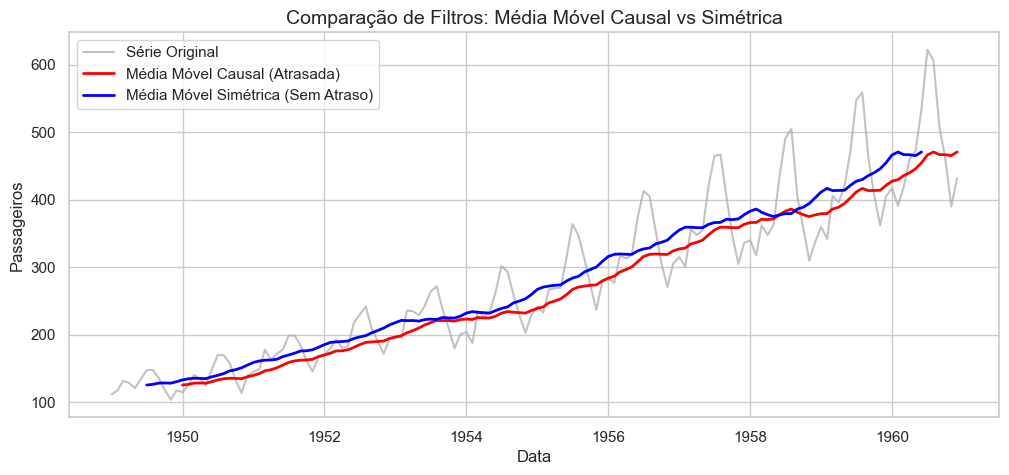

Conclusão Estatística: A média móvel baseada em valores passados (causal) apresenta um atraso sistemático em relação aos pontos de inflexão reais da série.
A média móvel simétrica corrige esse atraso, tornando-se o filtro padrão para decomposições clássicas offline, embora gere perdas de dados nas extremidades (NaNs).


In [19]:
# Ordem K = 13 para comparação justa
pass_ma = AP.rolling(window=13).mean()              # Passados 
sim_ma  = AP.rolling(window=13, center=True).mean() # Simétrica 

# Plotando e comparando o efeito de defasagem
plt.figure(figsize=(12, 5))
plt.plot(AP.index, AP.values, color='darkgrey', alpha=0.7, label='Série Original')
plt.plot(AP.index, pass_ma, color='red', linewidth=2, label='Média Móvel Causal (Atrasada)')
plt.plot(AP.index, sim_ma, color='blue', linewidth=2, label='Média Móvel Simétrica (Sem Atraso)')
plt.title('Comparação de Filtros: Média Móvel Causal vs Simétrica', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.show()

print("Conclusão Estatística: A média móvel baseada em valores passados (causal) apresenta um atraso sistemático em relação aos pontos de inflexão reais da série.")
print("A média móvel simétrica corrige esse atraso, tornando-se o filtro padrão para decomposições clássicas offline, embora gere perdas de dados nas extremidades (NaNs).")

### 5.5 Extração Manual Completa da Sazonalidade e do Ruído

Agora faremos o fechamento matemático da aula, executando o algoritmo de decomposição aditiva clássica inteiramente de forma manual via programação estruturada em Python.

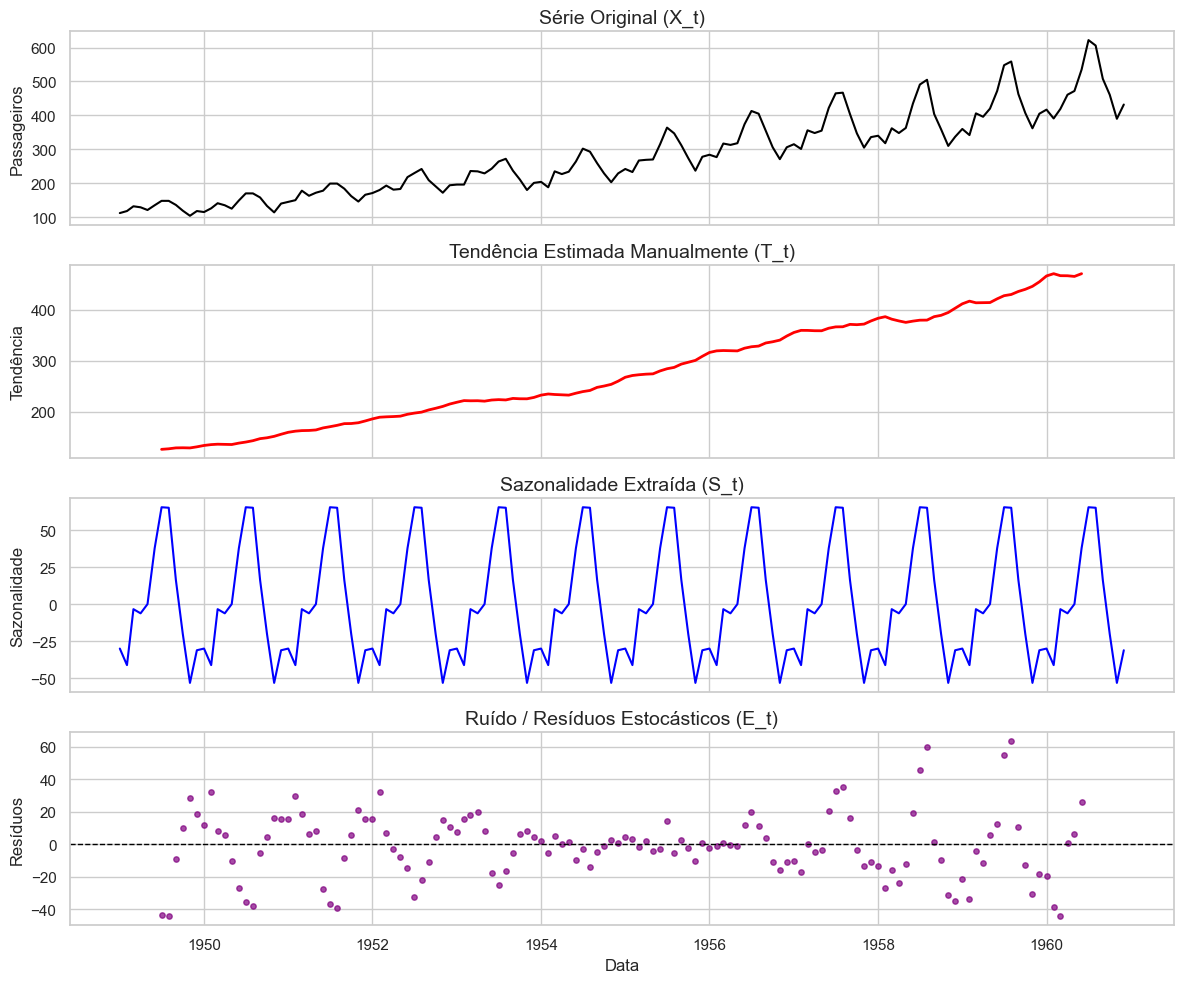

In [20]:
# Passo 1: Extrair a Tendência (T) usando um filtro simétrico de ordem 13 (conforme especificado no R)
T = AP.rolling(window=13, center=True).mean()

# Passo 2: Detendenciar a série para isolar Sazonalidade + Ruído (Z)
Z = AP - T

# Passo 3: Extrair o perfil sazonal fixo (S) calculando a média para cada mês do ano
# Agrupamos por mês do índice e tiramos a média descartando os NaNs presentes
fatores_sazonais_mensais = Z.groupby(Z.index.month).mean()

# Ajuste crucial: Garantir que a soma dos componentes sazonais seja zero no modelo aditivo
fatores_sazonais_mensais = fatores_sazonais_mensais - fatores_sazonais_mensais.mean()

# Replicar e projetar os fatores sazonais para toda a extensão temporal da série original
S = AP.index.month.map(fatores_sazonais_mensais)
S = pd.Series(S, index=AP.index)

# Passo 4: Calcular o Componente de Ruído/Resíduo Estocástico (E)
E = AP - T - S

# Passo 5: Construção do Gráfico Multi-Painel Completo das Componentes
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(AP.index, AP.values, color='black', linewidth=1.5)
axes[0].set_title('Série Original (X_t)')
axes[0].set_ylabel('Passageiros')

axes[1].plot(T.index, T.values, color='red', linewidth=2)
axes[1].set_title('Tendência Estimada Manualmente (T_t)')
axes[1].set_ylabel('Tendência')

axes[2].plot(S.index, S.values, color='blue', linewidth=1.5)
axes[2].set_title('Sazonalidade Extraída (S_t)')
axes[2].set_ylabel('Sazonalidade')

axes[3].scatter(E.index, E.values, color='purple', alpha=0.7, s=15)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Ruído / Resíduos Estocásticos (E_t)')
axes[3].set_ylabel('Resíduos')

plt.xlabel('Data')
plt.tight_layout()
plt.show()


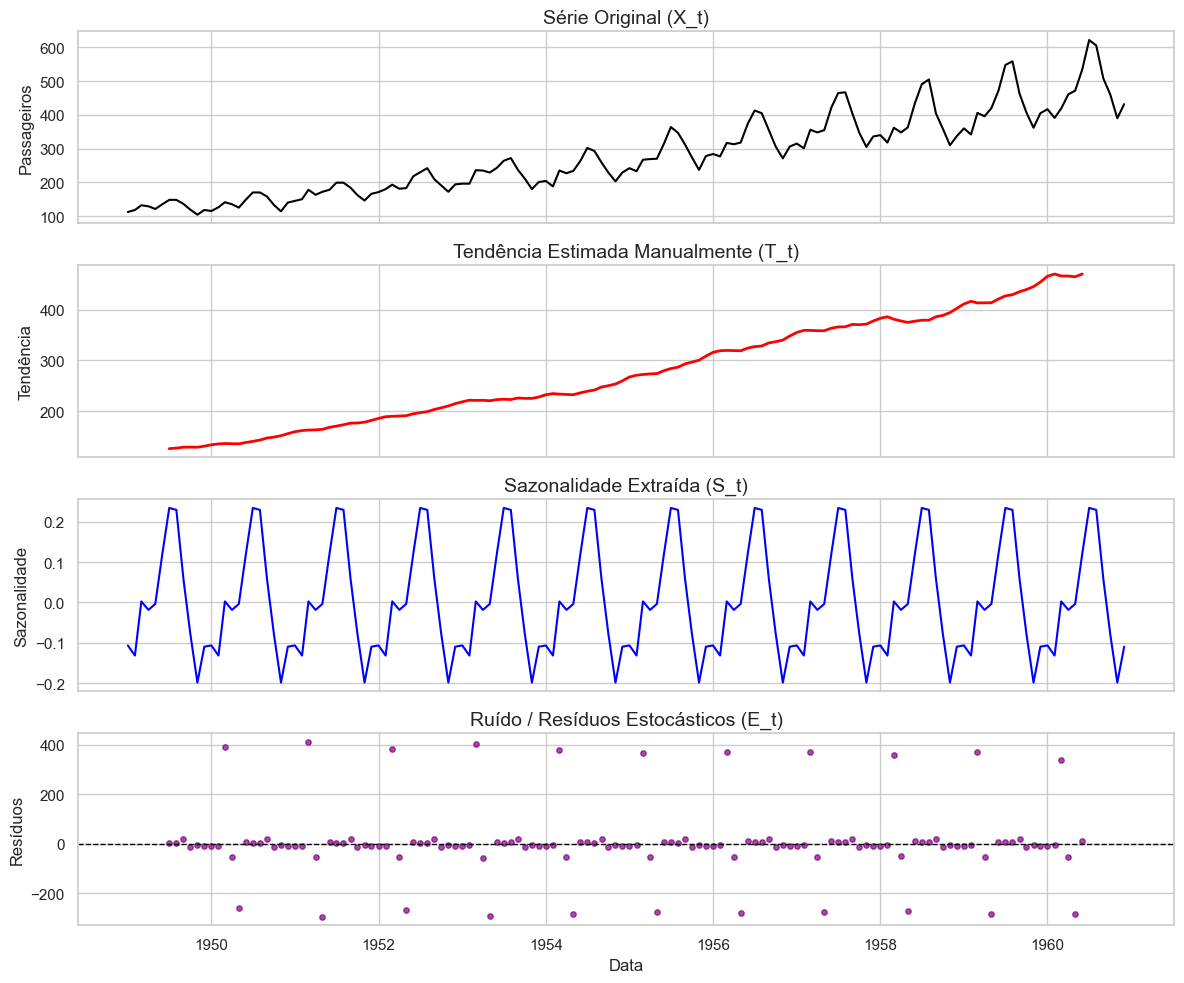

In [21]:
# Passo 1: Extrair a Tendência (T) usando um filtro simétrico de ordem 13 (conforme especificado no R)
T = AP.rolling(window=13, center=True).mean()

# Passo 2: Detendenciar a série para isolar Sazonalidade + Ruído (Z)
Z = AP / T

# Passo 3: Extrair o perfil sazonal fixo (S) calculando a média para cada mês do ano
# Agrupamos por mês do índice e tiramos a média descartando os NaNs presentes
fatores_sazonais_mensais = Z.groupby(Z.index.month).mean()

# Ajuste crucial: Garantir que a soma dos componentes sazonais seja zero no modelo aditivo
fatores_sazonais_mensais = fatores_sazonais_mensais - fatores_sazonais_mensais.mean()

# Replicar e projetar os fatores sazonais para toda a extensão temporal da série original
S = AP.index.month.map(fatores_sazonais_mensais)
S = pd.Series(S, index=AP.index)

# Passo 4: Calcular o Componente de Ruído/Resíduo Estocástico (E)
E = AP / (T * S)

# Passo 5: Construção do Gráfico Multi-Painel Completo das Componentes
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(AP.index, AP.values, color='black', linewidth=1.5)
axes[0].set_title('Série Original (X_t)')
axes[0].set_ylabel('Passageiros')

axes[1].plot(T.index, T.values, color='red', linewidth=2)
axes[1].set_title('Tendência Estimada Manualmente (T_t)')
axes[1].set_ylabel('Tendência')

axes[2].plot(S.index, S.values, color='blue', linewidth=1.5)
axes[2].set_title('Sazonalidade Extraída (S_t)')
axes[2].set_ylabel('Sazonalidade')

axes[3].scatter(E.index, E.values, color='purple', alpha=0.7, s=15)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Ruído / Resíduos Estocásticos (E_t)')
axes[3].set_ylabel('Resíduos')

plt.xlabel('Data')
plt.tight_layout()
plt.show()